# **AI Bootcamp – Week 9 | Day 2 Lab**

# Image Generation Workflows

## Objectives

In this lab, you will explore advanced image generation workflows using Stable Diffusion. Unlike Day 1, where images were generated only from text prompts, today you will learn how to transform existing images, edit specific regions, guide image generation using structural information, and explore text-to-video generation.

By the end of this lab, you will be able to:

- Generate images using Image-to-Image (img2img)
- Understand how the Strength parameter affects generated images
- Edit images using Inpainting
- Guide image generation with ControlNet
- Explore text-to-video generation
- Improve prompts through systematic experimentation

# Step 1 – Enable GPU

Stable Diffusion models require GPU acceleration for efficient execution.

Before continuing:

1. Click **Runtime**
2. Select **Change runtime type**
3. Choose **T4 GPU**
4. Click **Save**

Run the following code to verify that your GPU is available.

In [4]:
import torch

if torch.cuda.is_available():
    print("GPU Available")
    print(torch.cuda.get_device_name(0))
else:
    print("GPU NOT Available")

GPU Available
Tesla T4


# Step 2 – Install Required Libraries

Today's lab requires several additional libraries.

Run the following cell.



In [5]:
!pip -q install diffusers transformers accelerate safetensors opencv-python-headless

# Step 3 – Import Libraries


Complete the missing imports below.

Hint:

You will need

- torch
- numpy
- PIL
- matplotlib
- load_image
- export_to_video

In [6]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from diffusers.utils import load_image, export_to_video

# Image-to-Image (img2img)

Unlike Day 1, today's generation starts with an existing image.

Instead of creating a completely new image, Stable Diffusion modifies the original while preserving some of its structure.

The amount of change is controlled by the **Strength** parameter.
# Load the Image-to-Image Pipeline


Complete the missing code.

Model name:

runwayml/stable-diffusion-v1-5

In [7]:
from diffusers import StableDiffusionImg2ImgPipeline

pipe_img2img = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)
pipe_img2img = pipe_img2img.to("cuda")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

# Load the Sample Image

Run the following cell to download the sample image.

Feel free to swap in your own by uploading it to Colab and loading it with Image.open().

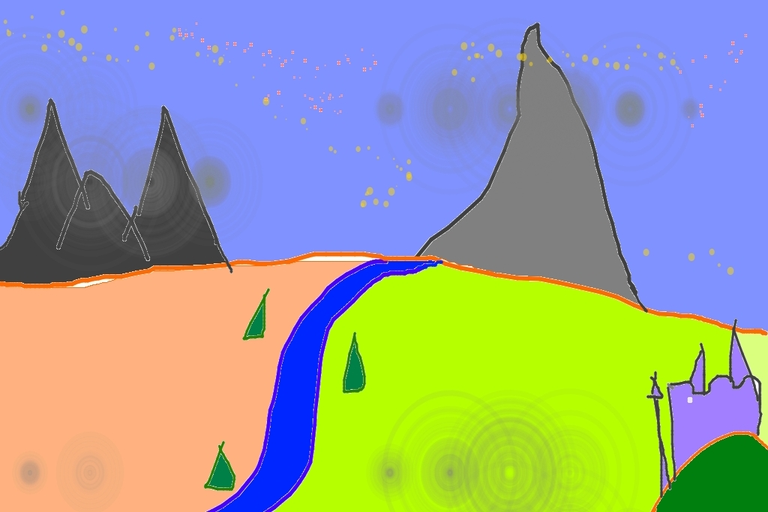

In [8]:
url = "https://raw.githubusercontent.com/CompVis/stable-diffusion/main/assets/stable-samples/img2img/sketch-mountains-input.jpg"
init_image = load_image(url).resize((768, 512))
init_image

 Experiment with the Strength Parameter

The **Strength** parameter determines how much the original image is modified.

Lower values preserve more of the original image.

Higher values generate a more dramatically changed image.


Generate the image using:

- Strength = 0.3
- Strength = 0.6
- Strength = 0.9

  0%|          | 0/15 [00:00<?, ?it/s]

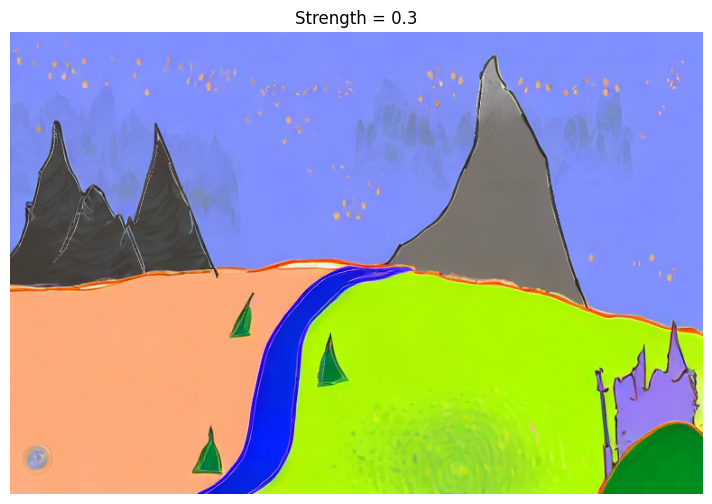

  0%|          | 0/30 [00:00<?, ?it/s]

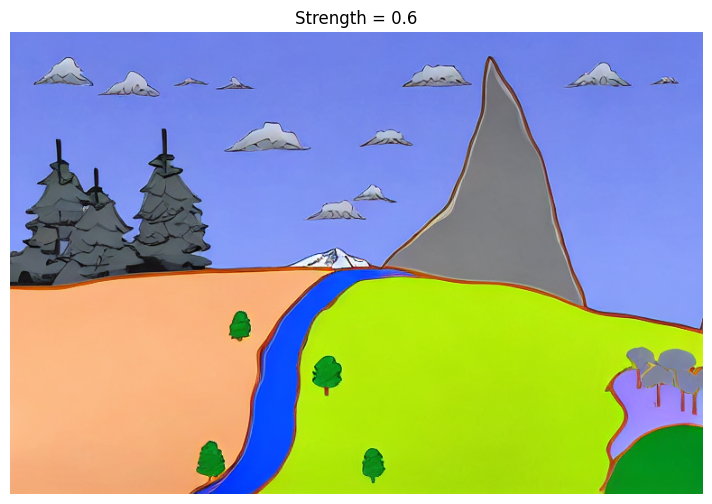

  0%|          | 0/45 [00:00<?, ?it/s]

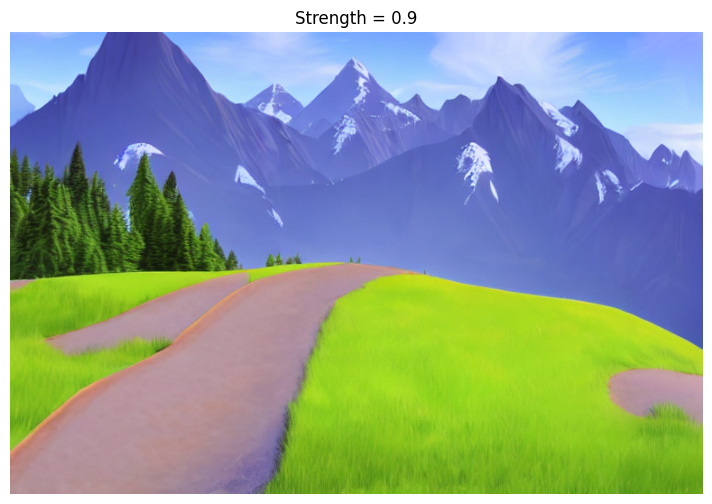

In [9]:
prompt = "a beautiful realistic mountain landscape, highly detailed"

for strength in [0.3, 0.6, 0.9]:

    result = pipe_img2img(
        prompt=prompt,
        image=init_image,
        strength=strength,
        guidance_scale=7.5
    ).images[0]

    plt.figure(figsize=(10, 6))
    plt.imshow(result)
    plt.title(f"Strength = {strength}")
    plt.axis("off")
    plt.show()

## Reflection

1. Which strength preserved the original image best?

2. Which strength produced the largest transformation?

3. Which value would you choose if the client wanted only small edits?

1).
0.3 preserved the original image best because lower strength gives Stable Diffusion less freedom to modify the input image.

2).0.9 produced the largest transformation because higher strength allows the model to introduce more changes.

3).I would choose approximately 0.3, because it preserves most of the original structure while allowing small modifications.

#  Inpainting

Instead of changing the whole image, Inpainting edits only the masked region.

The white region of the mask is regenerated.

The black region remains unchanged.

Load the Inpainting Pipeline


Complete the code below.

In [10]:
from diffusers import StableDiffusionInpaintPipeline

pipe_inpaint = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

pipe_inpaint = pipe_inpaint.to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Load an image and its mask.

The mask is white where you want new content generated, and black where the original should stay untouched.

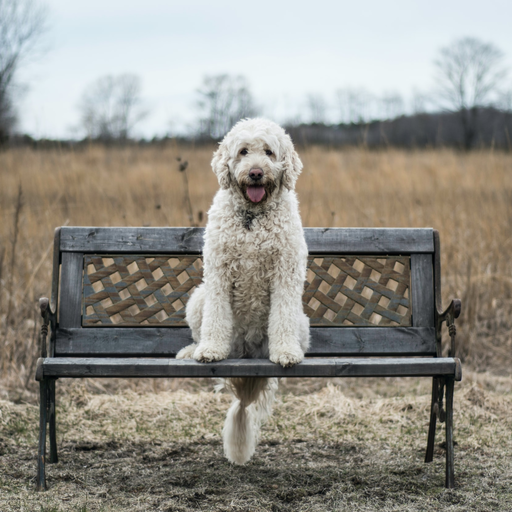

In [11]:
img_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo.png"
mask_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo_mask.png"

init_image = load_image(img_url).resize((512, 512))
mask_image = load_image(mask_url).resize((512, 512))

init_image

 Regenerate the masked region.

 **prompt =** "a majestic tiger sitting on a bench"

  0%|          | 0/50 [00:00<?, ?it/s]

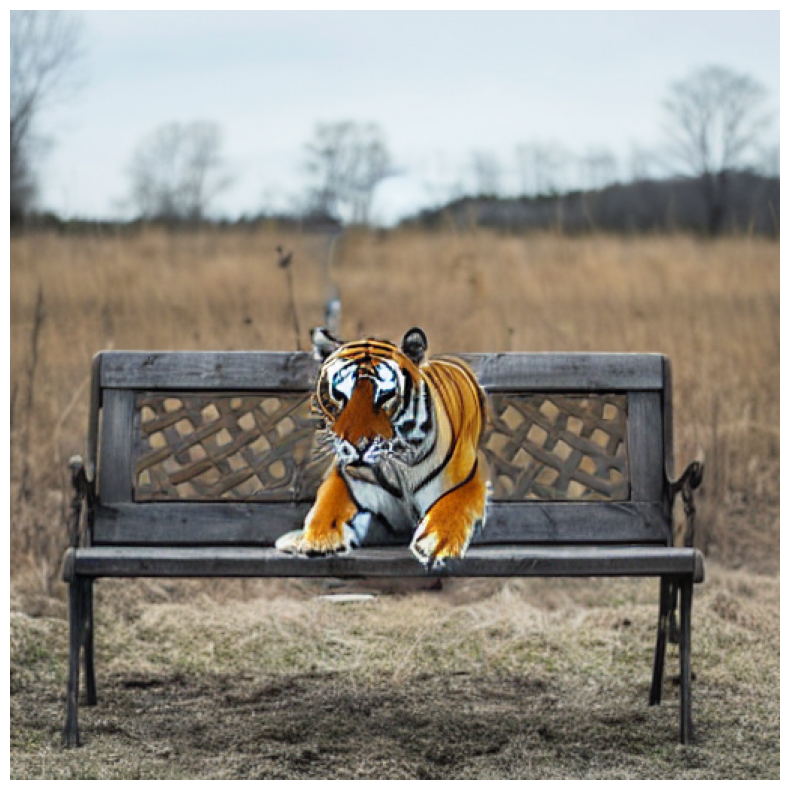

In [12]:
prompt = "a majestic tiger sitting on a bench"

result = pipe_inpaint(
    prompt=prompt,
    image=init_image,
    mask_image=mask_image,
    guidance_scale=7.5
).images[0]

plt.figure(figsize=(10, 10))
plt.imshow(result)
plt.axis("off")
plt.show()

##**Discussion**
    • Does the edited region blend naturally with the rest of the image?
    • What happens if you make the prompt vague vs. very specific?

1).It can blend naturally when the prompt, mask, lighting, colors, and surrounding context are consistent. However, imperfect masks or vague prompts can produce visible boundaries or unrealistic results.

2).For example:

an animal

The AI has less information about what you want, so the output can be unpredictable.

What happens with a specific prompt?

For example:

a majestic tiger sitting on a wooden bench, realistic fur, natural lighting

The model receives much more guidance and can generate a more appropriate result.

 # **ControlNet**

 Install and load ControlNet

In [13]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
import cv2

controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny",
    torch_dtype=torch.float16
)

pipe_cn = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B / 1.45GB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Create a Canny edge map from a reference image

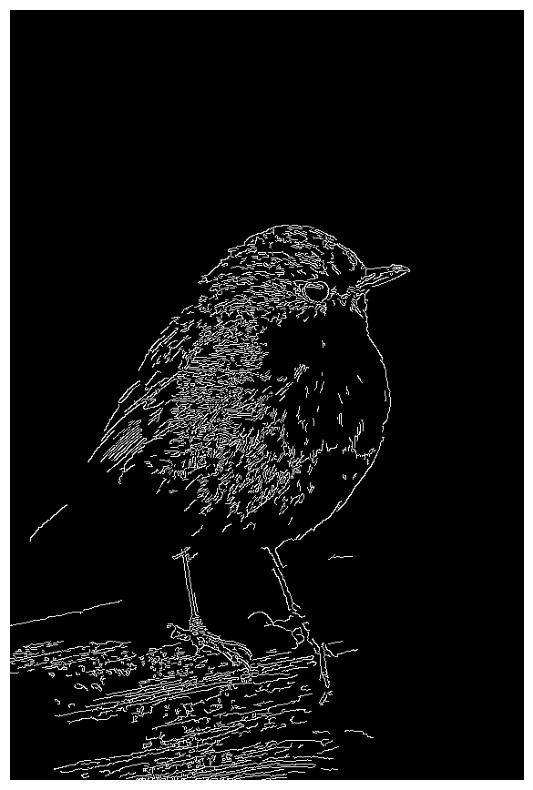

In [14]:
url = "https://huggingface.co/lllyasviel/sd-controlnet-canny/resolve/main/images/bird.png"
ref_image = load_image(url)

#write your code here
ref_image = np.array(ref_image)

image_gray = cv2.cvtColor(ref_image, cv2.COLOR_RGB2GRAY)

edges = cv2.Canny(image_gray, 100, 200)

edge_image = Image.fromarray(edges)

plt.figure(figsize=(10, 10))
plt.imshow(edge_image, cmap="gray")
plt.axis("off")
plt.show()

Generate guided by the edge map.

prompt = "a colorful parrot, highly detailed, studio lighting"

  0%|          | 0/30 [00:00<?, ?it/s]

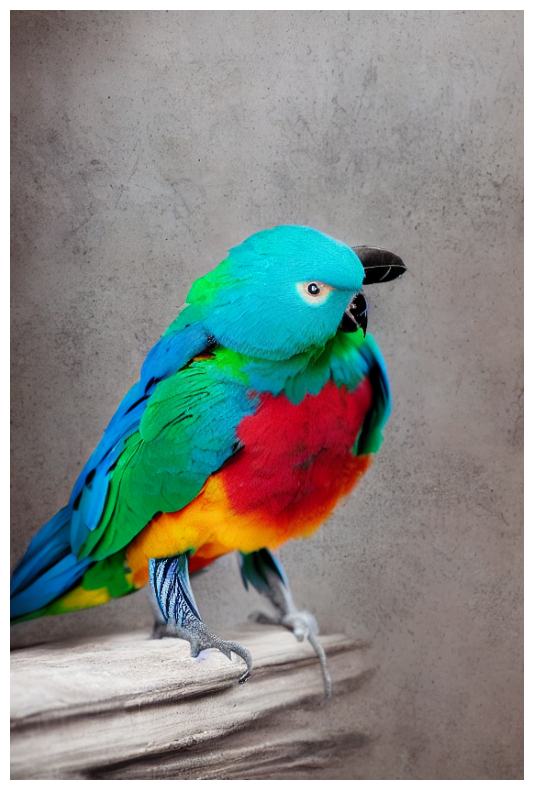

In [17]:
#write your code here
prompt = "a colorful parrot, highly detailed, studio lighting"

result = pipe_cn(
    prompt=prompt,
    image=edge_image,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

plt.figure(figsize=(10, 10))
plt.imshow(result)
plt.axis("off")
plt.show()


# **Text-to-Video Exploration**

Load a lightweight text-to-video model

In [18]:
from diffusers import DiffusionPipeline, DPMSolverMultistepScheduler

pipe_video = DiffusionPipeline.from_pretrained(
    "damo-vilab/text-to-video-ms-1.7b",
    torch_dtype=torch.float16,
    variant="fp16"
)
pipe_video.scheduler = DPMSolverMultistepScheduler.from_config(pipe_video.scheduler.config)
pipe_video.enable_model_cpu_offload()

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

The TextToVideoSDPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


Generate a short clip

In [19]:
prompt = "a golden retriever running on a beach at sunset"

video_frames = pipe_video(prompt, num_inference_steps=25).frames[0]
video_path = export_to_video(video_frames)
video_path

  0%|          | 0/25 [00:00<?, ?it/s]

'/tmp/tmp90seille.mp4'

Download the file from the Colab file browser (folder icon on the left) to watch it, or display it inline:

In [20]:
from IPython.display import Video
Video(video_path, embed=True)

Compare against a hosted demo.

Try the same prompt on one public text-to-video demo (e.g. a Hugging Face Space).

Note differences in quality, duration, and consistency.
# **Discussion**
    • How does video generation time compare to a single image?
    • What inconsistencies or artifacts do you notice across frames?

Video generation generally takes longer than generating a single image because the model must generate multiple frames while attempting to maintain consistency between them. Common artifacts include changes in the object's appearance, inconsistent motion, flickering, distorted body parts, and changes in the background between frames.